# Phase 4 — Feature Engineering

Built on Phase 3 best model: **XGBoost** (F1 Macro=0.8593, ROC-AUC=1.0000).  
Goal: reduce noise features to improve weak classes (Bot, XSS, Brute Force) and push F1 Macro toward 0.90.

| Step | Content |
|------|---------|
| 1 | Load Phase 3 artifacts |
| 2 | XGBoost feature importance (gain + cover) |
| 3 | Drop zero/low-importance features |
| 4 | Drop highly correlated pairs (`high_corr_to_drop.json`) |
| 5 | Retrain XGBoost on reduced feature set |
| 6 | Before / After comparison |

In [1]:
# ── Package installation (run once in Colab) ───────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", pkg])

try:
    import xgboost
except ImportError:
    install("xgboost")

try:
    import imblearn
except ImportError:
    install("imbalanced-learn")

print("Packages ready.")

Packages ready.


In [2]:
import pandas as pd
import numpy as np
import joblib
import json
import time
import warnings
from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Google Colab / Drive setup ─────────────────────────────────────────
try:
    import google.colab  # type: ignore
    IN_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUTS = Path('/content/drive/MyDrive/nids/outputs')
except ImportError:
    IN_COLAB = False
    OUTPUTS = Path("../outputs")

RESULTS_DIR = OUTPUTS / "results"
MODELS_DIR  = OUTPUTS / "models"
FIGURES_DIR = OUTPUTS / "figures"

RANDOM_STATE = 42
SAMPLE_FRAC  = 0.30   # same as Phase 3 for consistency
SMOTE_TARGET = 5_000

print(f"OUTPUTS → {OUTPUTS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUTPUTS → /content/drive/MyDrive/nids/outputs


## 1. Load Phase 3 Artifacts

In [3]:
preprocessor = joblib.load(MODELS_DIR / "preprocessor.joblib")
le           = joblib.load(MODELS_DIR / "label_encoder.joblib")
with open(RESULTS_DIR / "kept_features.json") as f:
    kept_features = json.load(f)

_corr_path = RESULTS_DIR / "high_corr_to_drop.json"
if _corr_path.exists():
    with open(_corr_path) as f:
        high_corr_to_drop = json.load(f)["to_drop"]
else:
    # Hardcoded from Phase 1 EDA (pairs with |r| >= 0.95)
    high_corr_to_drop = [
        "Bwd Header Length", "Bwd Packet Length Max", "Bwd Packet Length Mean",
        "Flow Duration", "Flow IAT Max", "Flow Packets/s", "Fwd Header Length",
        "Fwd PSH Flags", "Fwd Packet Length Max", "Fwd Packet Length Mean",
        "Fwd URG Flags", "Idle Max", "Idle Mean", "Max Packet Length",
        "Packet Length Mean", "RST Flag Count", "Subflow Bwd Packets",
        "Subflow Fwd Packets", "Total Backward Packets", "Total Fwd Packets",
        "Total Length of Bwd Packets", "Total Length of Fwd Packets",
    ]
    print("high_corr_to_drop.json not found — using hardcoded list from Phase 1")

print(f"Features after Phase 2 preprocessing : {len(kept_features)}")
print(f"High-corr features to drop           : {len(high_corr_to_drop)}")

high_corr_to_drop.json not found — using hardcoded list from Phase 1
Features after Phase 2 preprocessing : 67
High-corr features to drop           : 22


## 2. Data + Train/Test Split + SMOTE

In [4]:
df = pd.read_parquet(OUTPUTS / "cicids2017_clean.parquet")
df = df.groupby("Label", group_keys=False).apply(
    lambda g: g.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
)
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}  (sample_frac={SAMPLE_FRAC})")

feature_cols = [c for c in df.columns if c not in ("Label", "label_enc")]
df["label_enc"] = le.transform(df["Label"])
X = df[feature_cols]
y = df["label_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# SMOTE
class_counts      = Counter(y_train.tolist())
majority_class    = max(class_counts, key=class_counts.get)
sampling_strategy = {
    cls: SMOTE_TARGET
    for cls, cnt in class_counts.items()
    if cls != majority_class and cnt < SMOTE_TARGET
}
k_neighbors = min(5, min(class_counts[c] for c in sampling_strategy) - 1)

smote = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=k_neighbors, random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)
print(f"Train after SMOTE: {X_train_smote.shape}")

Rows: 756,239  |  Columns: 72  (sample_frac=0.3)
Train after SMOTE: (651786, 67)


## 3. XGBoost Feature Importance

Two metrics are used:
- **gain** — average improvement in loss per split (most informative for ranking)
- **cover** — average number of samples per split

In [5]:
xgb_phase3 = joblib.load(MODELS_DIR / "xgboost_comparison.joblib")

feature_names = kept_features  # list of feature names after Phase 2 preprocessing

importance_gain  = xgb_phase3.get_booster().get_score(importance_type="gain")
importance_cover = xgb_phase3.get_booster().get_score(importance_type="cover")

# XGBoost trained on numpy → feature names are f0,f1,... map back to real names
def fname(key):
    idx = int(key[1:])
    return kept_features[idx] if idx < len(kept_features) else key

imp_df = pd.DataFrame({
    "feature": [fname(k) for k in importance_gain.keys()],
    "gain":    list(importance_gain.values()),
    "cover":   [importance_cover.get(k, 0) for k in importance_gain.keys()],
}).sort_values("gain", ascending=False).reset_index(drop=True)

print(f"Features with non-zero importance: {len(imp_df)} / {len(kept_features)}")
print(f"\nTop 20 features by gain:")
print(imp_df.head(20).to_string(index=False))

Features with non-zero importance: 67 / 67

Top 20 features by gain:
                    feature        gain       cover
                 Active Std 1556.599121 1150.278442
      Bwd Packet Length Std 1471.345581 8677.957031
       Avg Bwd Segment Size 1002.477356 4783.242188
        Subflow Fwd Packets  718.702759  544.447021
     Total Backward Packets  564.024780 1574.891235
          Subflow Bwd Bytes  534.076538 2682.358398
                   Idle Max  481.120758  889.758911
     Packet Length Variance  457.089508 3596.630127
        Subflow Bwd Packets  435.632172 2574.963135
     Bwd Packet Length Mean  394.298065 3233.550293
        Average Packet Size  366.045471 5456.261230
              Fwd PSH Flags  361.731110  372.677063
Total Length of Fwd Packets  356.773834 1226.253906
           act_data_pkt_fwd  342.028046 1033.955078
          Fwd Header Length  338.879303  744.230591
                 Active Min  330.726471  995.517517
    Init_Win_bytes_backward  329.132080 1127.55

Saved → /content/drive/MyDrive/nids/outputs/figures/feature_importance_xgb.png


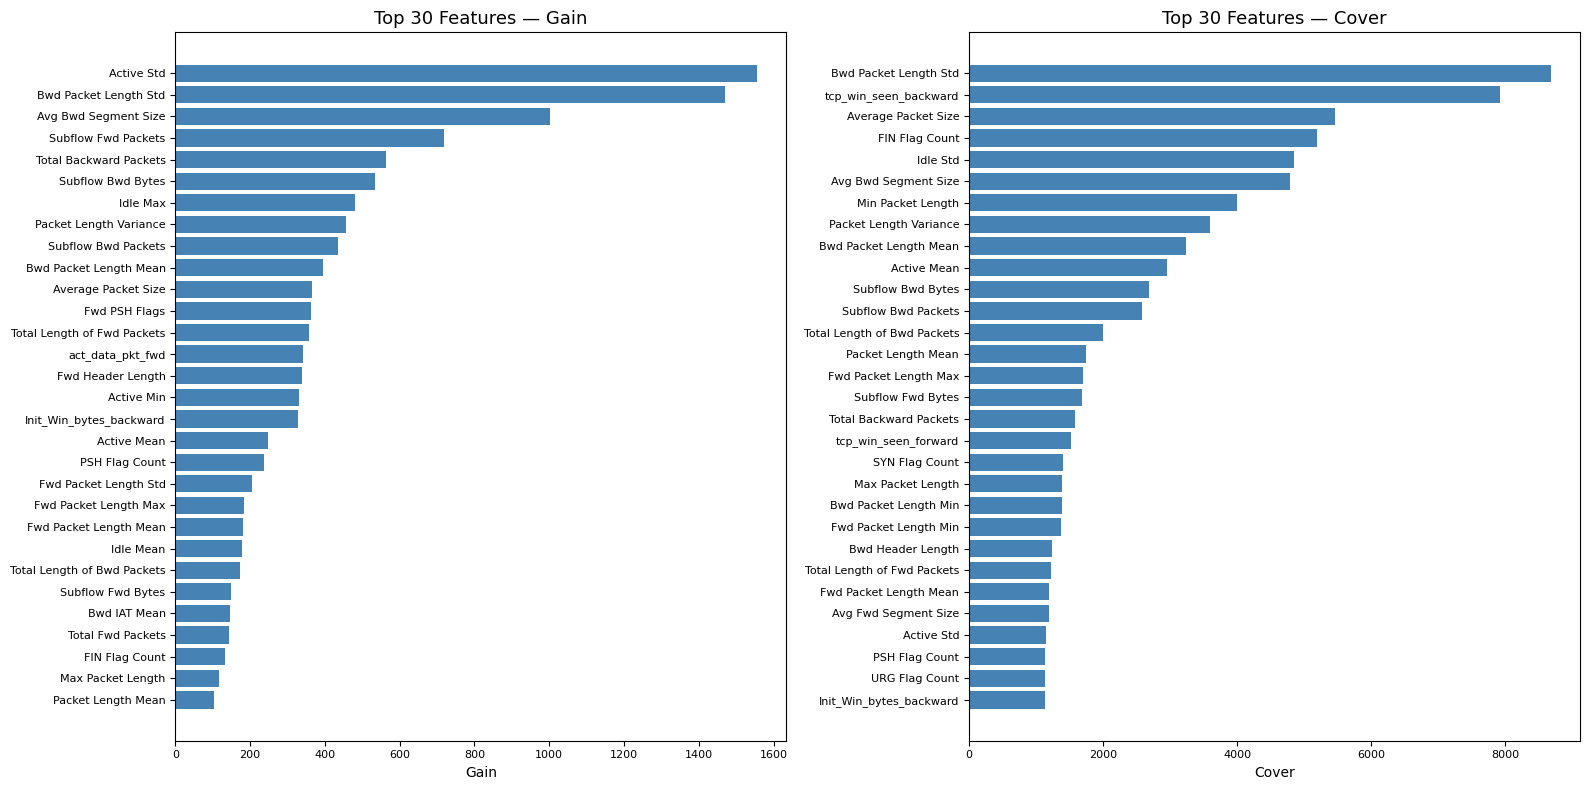

In [6]:
# ── Plot top 30 features ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, metric in zip(axes, ["gain", "cover"]):
    top = imp_df.nlargest(30, metric)
    ax.barh(top["feature"][::-1], top[metric][::-1], color="steelblue")
    ax.set_title(f"Top 30 Features — {metric.capitalize()}", fontsize=13)
    ax.set_xlabel(metric.capitalize())
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance_xgb.png", dpi=150, bbox_inches="tight")
print(f"Saved → {FIGURES_DIR / 'feature_importance_xgb.png'}")
plt.show()

## 4. Drop Zero-Importance + High-Correlation Features

In [7]:
# Features with zero gain (never used by any tree)
zero_imp = set(kept_features) - set(imp_df["feature"].tolist())
print(f"Zero-importance features: {len(zero_imp)}")
print(sorted(zero_imp))

# High-corr features to drop (from Phase 1 EDA)
print(f"\nHigh-corr features to drop: {len(high_corr_to_drop)}")
print(high_corr_to_drop)

# Combined drop set
to_drop = zero_imp | set(high_corr_to_drop)
selected_features = [f for f in kept_features if f not in to_drop]

print(f"\nFeatures: {len(kept_features)} → {len(selected_features)}  (dropped {len(to_drop)})")

Zero-importance features: 0
[]

High-corr features to drop: 22
['Bwd Header Length', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Flow Duration', 'Flow IAT Max', 'Flow Packets/s', 'Fwd Header Length', 'Fwd PSH Flags', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Fwd URG Flags', 'Idle Max', 'Idle Mean', 'Max Packet Length', 'Packet Length Mean', 'RST Flag Count', 'Subflow Bwd Packets', 'Subflow Fwd Packets', 'Total Backward Packets', 'Total Fwd Packets', 'Total Length of Bwd Packets', 'Total Length of Fwd Packets']

Features: 67 → 47  (dropped 22)


In [8]:
# Apply feature selection to train/test arrays
feat_idx = [kept_features.index(f) for f in selected_features]

X_train_sel = X_train_smote[:, feat_idx]
X_test_sel  = X_test_proc[:, feat_idx]

print(f"Train shape: {X_train_sel.shape}")
print(f"Test shape : {X_test_sel.shape}")

# Save selected feature list
with open(RESULTS_DIR / "selected_features.json", "w") as f:
    json.dump(selected_features, f, indent=2)
print(f"Saved → {RESULTS_DIR / 'selected_features.json'}")

Train shape: (651786, 47)
Test shape : (151248, 47)
Saved → /content/drive/MyDrive/nids/outputs/results/selected_features.json


## 5. Retrain XGBoost on Reduced Feature Set

In [9]:
del xgb_phase3
import gc; gc.collect()  # flush CUDA references before new model

xgb_feat = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0,
)

# ── Sanitise arrays before passing to XGBoost ─────────────────────────
X_train_sel = np.ascontiguousarray(X_train_sel, dtype=np.float32)
X_test_sel  = np.ascontiguousarray(X_test_sel,  dtype=np.float32)

X_train_sel = np.nan_to_num(X_train_sel, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sel  = np.nan_to_num(X_test_sel,  nan=0.0, posinf=0.0, neginf=0.0)

print(f"X_train_sel : shape={X_train_sel.shape}  dtype={X_train_sel.dtype}")
print(f"NaN: {np.isnan(X_train_sel).sum()}  Inf: {np.isinf(X_train_sel).sum()}")

t0 = time.time()
xgb_feat.fit(X_train_sel, y_train_smote)
train_time = time.time() - t0
print(f"Training time: {train_time/60:.1f} min")

joblib.dump(xgb_feat, MODELS_DIR / "xgboost_feat_eng.joblib")
print(f"Saved → {MODELS_DIR / 'xgboost_feat_eng.joblib'}")

X_train_sel : shape=(651786, 47)  dtype=float32
NaN: 0  Inf: 0
Training time: 0.6 min
Saved → /content/drive/MyDrive/nids/outputs/models/xgboost_feat_eng.joblib


# Load Phase 3 model here (deferred to avoid CUDA/CPU conflict during training)
xgb_phase3 = joblib.load(MODELS_DIR / "xgboost_comparison.joblib")

## 6. Before / After Comparison

In [10]:
# Reload Phase 3 model for comparison (was deleted before training)
xgb_phase3 = joblib.load(MODELS_DIR / "xgboost_comparison.joblib")

def get_metrics(model, X, y_true, label_encoder):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)
    return {
        "accuracy":    accuracy_score(y_true, y_pred),
        "f1_macro":    f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc":     roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted"),
    }, classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0)

before, report_before = get_metrics(xgb_phase3, X_test_proc,  y_test, le)
after,  report_after  = get_metrics(xgb_feat,   X_test_sel,   y_test, le)

print("\n" + "═"*52)
print(f"{'Metric':<18} {'Phase 3':>10} {'Phase 4':>10} {'Delta':>10}")
print("─"*52)
for k in ["f1_macro", "f1_weighted", "roc_auc", "accuracy"]:
    d = after[k] - before[k]
    print(f"{k:<18} {before[k]:>10.4f} {after[k]:>10.4f} {d:>+10.4f}")
print("═"*52)

print("\n─── Classification Report (Phase 4) ───")
print(report_after)


════════════════════════════════════════════════════
Metric                Phase 3    Phase 4      Delta
────────────────────────────────────────────────────
f1_macro               0.8593     0.8605    +0.0012
f1_weighted            0.9987     0.9987    -0.0000
roc_auc                1.0000     1.0000    -0.0000
accuracy               0.9987     0.9987    -0.0000
════════════════════════════════════════════════════

─── Classification Report (Phase 4) ───
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    125703
                       Bot       0.75      0.92      0.83       117
                      DDoS       1.00      1.00      1.00      7681
             DoS GoldenEye       1.00      1.00      1.00       617
                  DoS Hulk       1.00      1.00      1.00     10371
          DoS Slowhttptest       0.98      0.99      0.99       314
             DoS slowloris       1.00      0.99      0.99     

In [ ]:
# ── Save comparison to CSV ────────────────────────────────────────────
rows = []
for label, m in [("XGBoost Phase3 (all features)", before), ("XGBoost Phase4 (selected features)", after)]:
    rows.append({"model": label, **m})
comp_df = pd.DataFrame(rows)
comp_df.to_csv(RESULTS_DIR / "feat_eng_comparison.csv", index=False)
print(f"Saved → {RESULTS_DIR / 'feat_eng_comparison.csv'}")
print(comp_df.to_string(index=False))

Saved → /content/drive/MyDrive/nids/outputs/results/feat_eng_comparison.csv
                             model  accuracy  f1_macro  f1_weighted  roc_auc
     XGBoost Phase3 (all features)  0.998698  0.859287     0.998705 0.999978
XGBoost Phase4 (selected features)  0.998671  0.860473     0.998683 0.999977


: 